# Baseline Implementations Comparison

This notebook analyzes all baseline implementations for the H298_kcal prediction task. We compare:

- ChemProp
- FastProp
- Multimodel (MM)
- ChemBERTa
- Random Forest (RF) on different fingerprints:
  - Morgan fingerprints
  - MACCS fingerprints
  - RDK fingerprints
- MolCLR

We'll evaluate the models on both the final_test and final_aug_test datasets, computing various error metrics including RMSE, RMSRR, and RMSMRD.

## Imports and Utility Functions

First, let's import the necessary libraries and define our utility functions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib as mpl
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tabulate import tabulate
import os
import glob
from pathlib import Path

# Set plot style parameters
try:
    rc = mpl.rc_params_from_file("/home/akshatz/.config/matplotlib/matplotlibrc", use_default_template=False)
    sns.set_theme(style="white", rc=rc)
    mpl.rcParams.update(rc)
except:
    sns.set_theme(style="whitegrid")

# Define colors for plots
my_blue = "#83CDE6"
my_red = "#A4394A"
my_yellow = "#EECD62"

In [2]:
# Define rmsrr and rmsmrd functions
def compute_rmsrr(dataframe, key, label):
    """
    Compute Root Mean Square Resonance Range (RMSRR).
    
    For each group of resonance structures (identified by label),
    compute the max-min difference of the key value (predictions).
    Then take the root mean square of these differences.
    
    Args:
        dataframe: DataFrame containing predictions and labels
        key: Column name for predictions
        label: Column name for grouping (e.g., 'parent_smi')
    
    Returns:
        RMSRR value
    """
    max_min_diff = dataframe.groupby(label)[key].max() - dataframe.groupby(label)[key].min()
    squared_diff = max_min_diff ** 2
    mean_squared_diff = squared_diff.mean()
    
    rmsr = np.sqrt(mean_squared_diff)
    
    return rmsr

def compute_rmsmrd(dataframe, label_col, pred_col, true_col):
    """
    Compute Root Mean Square Maximum Resonance Deviation (RMSMRD).
    
    For each group of resonance structures (identified by label_col),
    compute the maximum absolute error between predictions and true values.
    Then take the root mean square of these maximum deviations.
    
    Args:
        dataframe: DataFrame containing predictions and true values
        label_col: Column name for grouping (e.g., 'parent_smi')
        pred_col: Column name for predictions
        true_col: Column name for true values
    
    Returns:
        RMSMRD value
    """
    errors = np.abs(dataframe[true_col] - dataframe[pred_col])
    error_df = pd.DataFrame({label_col: dataframe[label_col], 'error': errors})
    max_deviation = error_df.groupby(label_col)['error'].max()
    squared_deviation = max_deviation ** 2
    mean_squared_deviation = squared_deviation.mean()
    
    rmsmd = np.sqrt(mean_squared_deviation)
    
    return rmsmd

In [3]:
# Load datasets
all_data_set = pd.read_csv('dataset/all_data_set.csv')
all_aug_data_set = pd.read_csv('dataset/all_aug_data_set.csv')

## Define Baseline Paths

Let's collect the paths to all the test predictions from different baseline models.

In [4]:
# Define base directory
base_dir = "/home/akshatz/bond_order_free/k_means/rigr_h298_50k"

# Define model directories and test file patterns
model_dirs = {
    "chemprop": os.path.join(base_dir, "chemprop_baseline/output"),
    "fastprop": os.path.join(base_dir, "fastprop_baseline/output"),
    "ChemBERTa": os.path.join(base_dir, "ChemBERTa_baseline/output"),
    "MolCLR": os.path.join(base_dir, "MolCLR_baseline/output"),
    "MM": os.path.join(base_dir, "MM_baseline/output")
}

# Special handling for RF models with different fingerprint types
rf_dir = os.path.join(base_dir, "RF_baseline/output")
rf_fingerprints = ["Morgan", "MACCS", "RDKit"]

# Add RF models to the model_dirs dictionary
for fp in rf_fingerprints:
    model_dirs[f"RF-{fp}"] = rf_dir

# Initialize dictionaries to store results
test_files = {}
aug_test_files = {}
error_results = {}

# Define models that will have error bars (those with multiple splits)
models_with_error_bars = ["chemprop", "fastprop", "ChemBERTa", "MolCLR", "MM"]

# Find test prediction files
for model, directory in model_dirs.items():
    if model.startswith("RF-"):
        # Extract fingerprint type from model name
        fp_type = model.split("-")[1].lower()
        
        # Find files with fingerprint type in the name
        test_pattern = os.path.join(directory, f"*final_test*{fp_type}*preds.csv")
        test_files[model] = glob.glob(test_pattern)
        
        aug_test_pattern = os.path.join(directory, f"*final_aug_test*{fp_type}*preds.csv")
        aug_test_files[model] = glob.glob(aug_test_pattern)
    else:
        # For models with error bars (neural networks), get all 5 splits
        if model in models_with_error_bars:
            test_pattern = os.path.join(directory, f"*final_test*{model.lower()}*_[0-4].csv")
            aug_test_pattern = os.path.join(directory, f"*final_aug_test*{model.lower()}*_[0-4].csv")
        else:
            # For other models without error bars, use the general pattern
            test_pattern = os.path.join(directory, "*final_test*.csv")
            aug_test_pattern = os.path.join(directory, "*final_aug_test*.csv")
        
        test_files[model] = glob.glob(test_pattern)
        aug_test_files[model] = glob.glob(aug_test_pattern)

# Display found files
for model in model_dirs.keys():
    print(f"{model}:")
    print(f"  Test files: {len(test_files.get(model, []))} files found")
    if model in models_with_error_bars:
        # Show filenames for models with error bars to verify we found all splits
        print(f"  Files: {[os.path.basename(f) for f in test_files.get(model, [])]}")
    print(f"  Aug test files: {len(aug_test_files.get(model, []))} files found")
    print()

chemprop:
  Test files: 5 files found
  Files: ['final_test_with_chemprop_preds_3.csv', 'final_test_with_chemprop_preds_1.csv', 'final_test_with_chemprop_preds_2.csv', 'final_test_with_chemprop_preds_0.csv', 'final_test_with_chemprop_preds_4.csv']
  Aug test files: 5 files found

fastprop:
  Test files: 5 files found
  Files: ['final_test_with_fastprop_preds_3.csv', 'final_test_with_fastprop_preds_1.csv', 'final_test_with_fastprop_preds_4.csv', 'final_test_with_fastprop_preds_0.csv', 'final_test_with_fastprop_preds_2.csv']
  Aug test files: 5 files found

ChemBERTa:
  Test files: 5 files found
  Files: ['final_test_with_chemberta_preds_2.csv', 'final_test_with_chemberta_preds_4.csv', 'final_test_with_chemberta_preds_3.csv', 'final_test_with_chemberta_preds_0.csv', 'final_test_with_chemberta_preds_1.csv']
  Aug test files: 5 files found

MolCLR:
  Test files: 5 files found
  Files: ['final_test_with_molclr_preds_3.csv', 'final_test_with_molclr_preds_0.csv', 'final_test_with_molclr_preds

## Analysis of Final Test Set Results

Let's analyze the results on the final test set for each baseline model.

In [5]:
def analyze_test_results(model_name, file_paths):
    """
    Analyze test results for a model across multiple files (splits).
    
    Args:
        model_name: Name of the model
        file_paths: List of paths to the test predictions files
    
    Returns:
        Dictionary with error metrics including mean and std for multiple files
    """
    # Define models with error bars (neural networks with multiple splits)
    models_with_error_bars = ["chemprop", "fastprop", "ChemBERTa", "MolCLR", "MM"]
    
    # Check if we should process multiple files for this model
    if model_name in models_with_error_bars and len(file_paths) > 1:
        # Initialize containers to collect metrics across files
        overall_metrics = {'mae': [], 'rmse': [], 'r2': []}
        subset_metrics = {'res_radical': {'mae': [], 'rmse': [], 'r2': []},
                         'res_closed_shell': {'mae': [], 'rmse': [], 'r2': []},
                         'non_resonance': {'mae': [], 'rmse': [], 'r2': []}
                        }
        
        # Process each file and collect metrics
        for file_path in file_paths:
            result = analyze_single_test_file(model_name, file_path)
            if result:
                # Collect overall metrics
                overall_metrics['mae'].append(result['overall']['mae'])
                overall_metrics['rmse'].append(result['overall']['rmse'])
                overall_metrics['r2'].append(result['overall']['r2'])
                
                # Collect subset metrics
                for subset, metrics in result['subsets'].items():
                    if metrics['mae'] is not None:
                        subset_metrics[subset]['mae'].append(metrics['mae'])
                        subset_metrics[subset]['rmse'].append(metrics['rmse'])
                        subset_metrics[subset]['r2'].append(metrics['r2'])
        
        # Calculate mean and std for overall metrics
        overall_means = {'mae': np.mean(overall_metrics['mae']),
                        'rmse': np.mean(overall_metrics['rmse']),
                        'r2': np.mean(overall_metrics['r2'])  
                       }
        overall_stds = {'mae': np.std(overall_metrics['mae'], ddof=1),
                       'rmse': np.std(overall_metrics['rmse'], ddof=1),
                       'r2': np.std(overall_metrics['r2'], ddof=1)
                      }
        
        # Calculate mean and std for subset metrics
        subset_means = {}
        subset_stds = {}
        for subset, metrics in subset_metrics.items():
            if metrics['mae']: # If we have metrics for this subset
                subset_means[subset] = {'mae': np.mean(metrics['mae']), 
                                       'rmse': np.mean(metrics['rmse']),
                                       'r2': np.mean(metrics['r2'])  
                                      }
                subset_stds[subset] = {'mae': np.std(metrics['mae'], ddof=1),
                                      'rmse': np.std(metrics['rmse'], ddof=1),
                                      'r2': np.std(metrics['r2'], ddof=1)
                                     }
            else:
                subset_means[subset] = {'mae': None, 'rmse': None, 'r2': None}
                subset_stds[subset] = {'mae': None, 'rmse': None, 'r2': None}
        
        # Return all metrics with their means and standard deviations
        return {
            'overall': {'mae': overall_means['mae'], 'rmse': overall_means['rmse'], 'r2': overall_means['r2']},
            'overall_std': {'mae': overall_stds['mae'], 'rmse': overall_stds['rmse'], 'r2': overall_stds['r2']},
            'subsets': subset_means,
            'subsets_std': subset_stds,
            'has_error_bars': True,
            # Use dataframe from last file for visualization purposes
            'df': analyze_single_test_file(model_name, file_paths[0])['df'] if file_paths else None,
            'pred_col': analyze_single_test_file(model_name, file_paths[0])['pred_col'] if file_paths else None
        }
    else:
        # For models without error bars or with only one file, use the original analysis
        result = analyze_single_test_file(model_name, file_paths[0]) if file_paths else None
        if result:
            result['has_error_bars'] = False
            # Add empty std fields for consistency
            result['overall_std'] = {'mae': None, 'rmse': None, 'r2': None}
            result['subsets_std'] = {subset: {'mae': None, 'rmse': None, 'r2': None} 
                                   for subset in result['subsets'].keys()}
        return result

def analyze_single_test_file(model_name, file_path):
    """
    Analyze a single test file for a model.
    
    Args:
        model_name: Name of the model
        file_path: Path to the test predictions file
    
    Returns:
        Dictionary with error metrics
    """
    try:
        # Read CSV file
        df = pd.read_csv(file_path)
        
        # Identify prediction column - different models might use different column names
        pred_cols = [col for col in df.columns if 'pred' in col.lower()]
        if not pred_cols:
            print(f"No prediction column found in {file_path}")
            return None
            
        pred_col = pred_cols[0]
        
        # Merge with dataset to get subsets
        df = df.merge(all_data_set[["resonance_smis", "subset"]], how="left", on="resonance_smis")
        
        # Calculate metrics for the entire dataset
        y_true = df["H298_kcal"].values
        y_pred = df[pred_col].values
        
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        # Calculate metrics for each subset
        subsets = {'res_radical', 'res_closed_shell', 'non_resonance'}
        subset_metrics = {}
        
        for subset in subsets:
            subset_df = df[df['subset'] == subset]
            if len(subset_df) == 0:
                subset_metrics[subset] = {
                    'mae': None, 'rmse': None, 'r2': None
                }
                continue
                
            subset_true = subset_df['H298_kcal'].values
            subset_pred = subset_df[pred_col].values
            
            subset_metrics[subset] = {
                'mae': mean_absolute_error(subset_true, subset_pred),
                'rmse': np.sqrt(mean_squared_error(subset_true, subset_pred)),
                'r2': r2_score(subset_true, subset_pred)
            }
        
        # Return all metrics
        return {
            'overall': {'mae': mae, 'rmse': rmse, 'r2': r2},
            'subsets': subset_metrics,
            'df': df,  # Keep the dataframe for later use
            'pred_col': pred_col
        }
    
    except Exception as e:
        print(f"Error analyzing {model_name} test results in file {os.path.basename(file_path)}: {e}")
        return None

# Process test results for all models
test_results = {}
for model, files in test_files.items():
    if files:  # If there are files for this model
        test_results[model] = analyze_test_results(model, files)  # Pass all files for processing
    else:
        print(f"No test files found for {model}")

# Create a summary dataframe for the final test results
test_summary_data = []
for model, result in test_results.items():
    if result:
        # Add overall metrics
        test_summary_data.append({
            'Model': model,
            'Subset': 'All',
            'MAE': result['overall']['mae'],
            'RMSE': result['overall']['rmse'],
            'MAE_std': result['overall_std']['mae'],
            'RMSE_std': result['overall_std']['rmse'],
            'Has_Error_Bars': result['has_error_bars'],
            'R²': result['overall']['r2']
        })
        
        # Add subset metrics
        for subset, metrics in result['subsets'].items():
            if metrics['mae'] is not None:  # If the subset exists
                test_summary_data.append({
                    'Model': model,
                    'Subset': subset,
                    'MAE': metrics['mae'],
                    'RMSE': metrics['rmse'],
                    'MAE_std': result['subsets_std'][subset]['mae'],
                    'RMSE_std': result['subsets_std'][subset]['rmse'],
                    'Has_Error_Bars': result['has_error_bars'],
                    'R²': metrics['r2']
                })

# Create the summary dataframe
test_summary_df = pd.DataFrame(test_summary_data)

# Display the summary table
print("\nSummary of Final Test Set Results:\n")
test_summary_pivot = test_summary_df.pivot_table(
    index=['Model', 'Subset'],
    values=['MAE', 'RMSE', 'MAE_std', 'RMSE_std', 'R²'],
    aggfunc='first'
)

print(tabulate(test_summary_pivot.reset_index(), headers='keys', tablefmt='pretty'))


Summary of Final Test Set Results:

+----+-----------+------------------+--------------------+----------------------+--------------------+---------------------+--------------------+
|    |   Model   |      Subset      |        MAE         |       MAE_std        |        RMSE        |      RMSE_std       |         R²         |
+----+-----------+------------------+--------------------+----------------------+--------------------+---------------------+--------------------+
| 0  | ChemBERTa |       All        | 12.692009232298389 |  0.2899872191562709  | 17.958072003947116 | 0.49964087170097254 | 0.9164274679051134 |
| 1  | ChemBERTa |  non_resonance   | 6.173547924111948  | 0.25568004371664577  | 8.236297628946815  | 0.2649740770366585  | 0.9754426605104966 |
| 2  | ChemBERTa | res_closed_shell | 10.18418569294648  | 0.41786533779703317  | 13.038423750341664 | 0.5665036245114022  | 0.9532086236425409 |
| 3  | ChemBERTa |   res_radical    | 17.868939478155745 |  0.7639634156144548  | 23.91

## Analysis of Final Augmented Test Set Results

Now let's analyze the results on the final augmented test set. We'll also compute RMSRR and RMSMRD metrics for resonance structures.

In [6]:
def analyze_aug_test_results(model_name, file_paths):
    """
    Analyze augmented test results for a model across multiple files (splits).
    
    Args:
        model_name: Name of the model
        file_paths: List of paths to the augmented test predictions files
    
    Returns:
        Dictionary with error metrics including mean and std for multiple files
    """
    # Define models with error bars (neural networks with multiple splits)
    models_with_error_bars = ["chemprop", "fastprop", "ChemBERTa", "MolCLR", "MM"]
    
    # Check if we should process multiple files for this model
    if model_name in models_with_error_bars and len(file_paths) > 1:
        # Initialize containers to collect metrics across files
        overall_metrics = {'mae': [], 'rmse': [], 'r2': []}
        subset_metrics = {
            'res_radical': {'mae': [], 'rmse': [], 'r2': [], 'rmsrr': [], 'rmsmrd': []},
            'res_closed_shell': {'mae': [], 'rmse': [], 'r2': [], 'rmsrr': [], 'rmsmrd': []},
            'non_resonance': {'mae': [], 'rmse': [], 'r2': [], 'rmsrr': [], 'rmsmrd': []}
        }
        
        # Process each file and collect metrics
        for file_path in file_paths:
            result = analyze_single_aug_test_file(model_name, file_path)
            if result:
                # Collect overall metrics
                overall_metrics['mae'].append(result['overall']['mae'])
                overall_metrics['rmse'].append(result['overall']['rmse'])
                overall_metrics['r2'].append(result['overall']['r2'])
                
                # Collect subset metrics
                for subset, metrics in result['subsets'].items():
                    if metrics['mae'] is not None:
                        subset_metrics[subset]['mae'].append(metrics['mae'])
                        subset_metrics[subset]['rmse'].append(metrics['rmse'])
                        subset_metrics[subset]['r2'].append(metrics['r2'])
                        if subset in ['res_radical', 'res_closed_shell'] and metrics.get('rmsrr') is not None:
                            subset_metrics[subset]['rmsrr'].append(metrics['rmsrr'])
                            subset_metrics[subset]['rmsmrd'].append(metrics['rmsmrd'])
        
        # Calculate mean and std for overall metrics
        overall_means = {
            'mae': np.mean(overall_metrics['mae']),
            'rmse': np.mean(overall_metrics['rmse']),
            'r2': np.mean(overall_metrics['r2'])
        }
        overall_stds = {
            'mae': np.std(overall_metrics['mae'], ddof=1),
            'rmse': np.std(overall_metrics['rmse'], ddof=1),
            'r2': np.std(overall_metrics['r2'], ddof=1)
        }
        
        # Calculate mean and std for subset metrics
        subset_means = {}
        subset_stds = {}
        for subset, metrics in subset_metrics.items():
            if metrics['mae']:  # If we have metrics for this subset
                metric_means = {
                    'mae': np.mean(metrics['mae']),
                    'rmse': np.mean(metrics['rmse']),
                    'r2': np.mean(metrics['r2'])
                }
                metric_stds = {
                    'mae': np.std(metrics['mae'], ddof=1),
                    'rmse': np.std(metrics['rmse'], ddof=1),
                    'r2': np.std(metrics['r2'], ddof=1)
                }
                
                # Add RMSRR and RMSMRD for resonance subsets
                if subset in ['res_radical', 'res_closed_shell'] and metrics['rmsrr']:
                    metric_means['rmsrr'] = np.mean(metrics['rmsrr'])
                    metric_means['rmsmrd'] = np.mean(metrics['rmsmrd'])
                    metric_stds['rmsrr'] = np.std(metrics['rmsrr'], ddof=1)
                    metric_stds['rmsmrd'] = np.std(metrics['rmsmrd'], ddof=1)
                else:
                    metric_means['rmsrr'] = None
                    metric_means['rmsmrd'] = None
                    metric_stds['rmsrr'] = None
                    metric_stds['rmsmrd'] = None
                
                subset_means[subset] = metric_means
                subset_stds[subset] = metric_stds
            else:
                subset_means[subset] = {'mae': None, 'rmse': None, 'r2': None, 'rmsrr': None, 'rmsmrd': None}
                subset_stds[subset] = {'mae': None, 'rmse': None, 'r2': None, 'rmsrr': None, 'rmsmrd': None}
        
        # Return all metrics with their means and standard deviations
        return {
            'overall': overall_means,
            'overall_std': overall_stds,
            'subsets': subset_means,
            'subsets_std': subset_stds,
            'has_error_bars': True,
            # Use dataframe from last file for visualization purposes
            'df': analyze_single_aug_test_file(model_name, file_paths[0])['df'] if file_paths else None,
            'pred_col': analyze_single_aug_test_file(model_name, file_paths[0])['pred_col'] if file_paths else None
        }
    else:
        # For models without error bars or with only one file, use the original analysis
        result = analyze_single_aug_test_file(model_name, file_paths[0]) if file_paths else None
        if result:
            result['has_error_bars'] = False
            # Add empty std fields for consistency
            result['overall_std'] = {'mae': None, 'rmse': None, 'r2': None}
            result['subsets_std'] = {
                subset: {'mae': None, 'rmse': None, 'r2': None, 'rmsrr': None, 'rmsmrd': None}
                for subset in result['subsets'].keys()
            }
        return result

def analyze_single_aug_test_file(model_name, file_path):
    """
    Analyze a single augmented test file for a model.
    
    Args:
        model_name: Name of the model
        file_path: Path to the augmented test predictions file
    
    Returns:
        Dictionary with error metrics
    """
    try:
        # Read CSV file
        df = pd.read_csv(file_path)
        
        # Identify prediction column
        pred_cols = [col for col in df.columns if 'pred' in col.lower()]
        if not pred_cols:
            print(f"No prediction column found in {file_path}")
            return None
            
        pred_col = pred_cols[0]
        
        # Merge with dataset to get subsets and parent_smi
        df = df.merge(all_aug_data_set[["resonance_smis", "subset", "parent_smi"]], 
                     how="left", on="resonance_smis")
        
        # Calculate metrics for the entire dataset
        y_true = df["H298_kcal"].values
        y_pred = df[pred_col].values
        
        mae = mean_absolute_error(y_true, y_pred)
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        r2 = r2_score(y_true, y_pred)
        
        # Calculate metrics for each subset
        subsets = {'res_radical', 'res_closed_shell', 'non_resonance'}
        subset_metrics = {}
        
        for subset in subsets:
            subset_df = df[df['subset'] == subset]
            if len(subset_df) == 0:
                subset_metrics[subset] = {
                    'mae': None, 'rmse': None, 'r2': None, 'rmsrr': None, 'rmsmrd': None
                }
                continue
                
            subset_true = subset_df['H298_kcal'].values
            subset_pred = subset_df[pred_col].values
            
            metrics = {
                'mae': mean_absolute_error(subset_true, subset_pred),
                'rmse': np.sqrt(mean_squared_error(subset_true, subset_pred)),
                'r2': r2_score(subset_true, subset_pred)
            }
            
            # Calculate RMSRR and RMSMRD only for resonance structures
            if subset in ['res_radical', 'res_closed_shell']:
                metrics['rmsrr'] = compute_rmsrr(subset_df, pred_col, 'parent_smi')
                metrics['rmsmrd'] = compute_rmsmrd(subset_df, 'parent_smi', pred_col, 'H298_kcal')
            else:
                metrics['rmsrr'] = None
                metrics['rmsmrd'] = None
                
            subset_metrics[subset] = metrics
        
        # Return all metrics
        return {
            'overall': {'mae': mae, 'rmse': rmse, 'r2': r2},
            'subsets': subset_metrics,
            'df': df,  # Keep the dataframe for later use
            'pred_col': pred_col
        }
    
    except Exception as e:
        print(f"Error analyzing {model_name} augmented test results in file {os.path.basename(file_path)}: {e}")
        return None

# Process augmented test results for all models
aug_test_results = {}
for model, files in aug_test_files.items():
    if files:  # If there are files for this model
        aug_test_results[model] = analyze_aug_test_results(model, files)  # Pass all files for processing
    else:
        print(f"No augmented test files found for {model}")

# Create a summary dataframe for the augmented test results
aug_test_summary_data = []
for model, result in aug_test_results.items():
    if result:
        # Add overall metrics
        aug_test_summary_data.append({
            'Model': model,
            'Subset': 'All',
            'MAE': result['overall']['mae'],
            'RMSE': result['overall']['rmse'],
            'MAE_std': result['overall_std']['mae'],
            'RMSE_std': result['overall_std']['rmse'],
            'Has_Error_Bars': result['has_error_bars'],
            'R²': result['overall']['r2'],
            'RMSRR': None,
            'RMSMRD': None,
            'RMSRR_std': None,
            'RMSMRD_std': None
        })
        
        # Add subset metrics
        for subset, metrics in result['subsets'].items():
            if metrics['mae'] is not None:  # If the subset exists
                aug_test_summary_data.append({
                    'Model': model,
                    'Subset': subset,
                    'MAE': metrics['mae'],
                    'RMSE': metrics['rmse'],
                    'MAE_std': result['subsets_std'][subset]['mae'],
                    'RMSE_std': result['subsets_std'][subset]['rmse'],
                    'Has_Error_Bars': result['has_error_bars'],
                    'R²': metrics['r2'],
                    'RMSRR': metrics['rmsrr'],
                    'RMSMRD': metrics['rmsmrd'],
                    'RMSRR_std': result['subsets_std'][subset]['rmsrr'],
                    'RMSMRD_std': result['subsets_std'][subset]['rmsmrd']
                })

# Create the summary dataframe
aug_test_summary_df = pd.DataFrame(aug_test_summary_data)

# Display the summary table
print("\nSummary of Final Augmented Test Set Results:\n")
aug_test_summary_pivot = aug_test_summary_df.pivot_table(
    index=['Model', 'Subset'],
    values=['MAE', 'RMSE', 'MAE_std', 'RMSE_std', 'R²', 'RMSRR', 'RMSMRD', 'RMSRR_std', 'RMSMRD_std'],
    aggfunc='first'
)

print(tabulate(aug_test_summary_pivot.reset_index(), headers='keys', tablefmt='pretty'))


Summary of Final Augmented Test Set Results:

+----+-----------+------------------+--------------------+---------------------+--------------------+---------------------+--------------------+---------------------+--------------------+---------------------+--------------------+
|    |   Model   |      Subset      |        MAE         |       MAE_std       |        RMSE        |      RMSE_std       |       RMSMRD       |     RMSMRD_std      |       RMSRR        |      RMSRR_std      |         R²         |
+----+-----------+------------------+--------------------+---------------------+--------------------+---------------------+--------------------+---------------------+--------------------+---------------------+--------------------+
| 0  | ChemBERTa |       All        | 14.403508631865899 | 0.40873014633095917 | 19.952280957823167 |  0.632781771201315  |        nan         |         nan         |        nan         |         nan         | 0.8948130912787983 |
| 1  | ChemBERTa |  non_reson

## Performance Visualization with Subsets on X-axis

Creating visualizations with the subsets on the x-axis and different colors for each model.

In [7]:
colors = sns.color_palette("CMRmap", 7)
colors

[(0.15058823529411763, 0.15, 0.5009803921568627),
 (0.3023529411764706, 0.1503921568627451, 0.7480392156862745),
 (0.6047058823529412, 0.20058823529411765, 0.4958823529411765),
 (0.9984313725490196, 0.25392156862745097, 0.1476470588235294),
 (0.9, 0.5049019607843137, 0.00196078431372549),
 (0.9, 0.7535294117647059, 0.10941176470588236),
 (0.9027450980392157, 0.9027450980392157, 0.5137254901960784)]

In [8]:
# Define subset order for consistent plotting
subset_order = ['All', 'res_radical', 'res_closed_shell', 'non_resonance']
subset_labels = ['All', 'Resonance\nradical', 'Resonance\nclosed shell', 'No\nresonance']

# Define fixed model order for consistent plotting
fixed_model_order = ["chemprop", "fastprop", "MM", "MolCLR", "ChemBERTa", "RF-MACCS", "RF-Morgan", "RF-RDKit"]

model_colors = {
    "chemprop":  '#ffe66d',
    "fastprop":  '#f19658',
    "MM":        '#f0a3a3',
    "ChemBERTa": '#4C9F70',
    "MolCLR":    '#D47A87',
    "RF-Morgan": '#4989c4',  
    "RF-MACCS":  '#76a9d6',   
    "RF-RDKit":    '#3568a0',  
}

# Define models with error bars for easier reference
models_with_error_bars = ["chemprop", "fastprop", "ChemBERTa", "MolCLR", "MM"]

# Prepare data for plotting
def prepare_plot_data(summary_df):
    # Replace subset names with more readable labels
    subset_mapping = {
        'All': 'All',
        'res_radical': 'Resonance\nradical',
        'res_closed_shell': 'Resonance\nclosed shell',
        'non_resonance': 'No\nresonance'
    }
    
    plot_df = summary_df.copy()
    plot_df['Subset'] = plot_df['Subset'].map(subset_mapping)
    
    return plot_df

# Create test and augmented test summary dataframes
test_summary_data = []
for model in test_results.keys():
    if test_results[model]:
        # Add overall metrics
        test_summary_data.append({
            'Model': model,
            'Subset': 'All',
            'RMSE': test_results[model]['overall']['rmse'],
            'RMSE_std': test_results[model]['overall_std']['rmse'],
            'Has_Error_Bars': model in models_with_error_bars
        })
        
        # Add subset metrics
        for subset, metrics in test_results[model]['subsets'].items():
            if metrics['rmse'] is not None:  # If the subset exists
                test_summary_data.append({
                    'Model': model,
                    'Subset': subset,
                    'RMSE': metrics['rmse'],
                    'RMSE_std': test_results[model]['subsets_std'][subset]['rmse'],
                    'Has_Error_Bars': model in models_with_error_bars
                })

test_summary_df = pd.DataFrame(test_summary_data)

aug_test_summary_data = []
for model in aug_test_results.keys():
    if aug_test_results[model]:
        # Add overall metrics
        aug_test_summary_data.append({
            'Model': model,
            'Subset': 'All',
            'RMSE': aug_test_results[model]['overall']['rmse'],
            'RMSE_std': aug_test_results[model]['overall_std']['rmse'],
            'Has_Error_Bars': model in models_with_error_bars,
            'RMSRR': None,
            'RMSMRD': None,
            'RMSRR_std': None,
            'RMSMRD_std': None
        })
        
        # Add subset metrics
        for subset, metrics in aug_test_results[model]['subsets'].items():
            if metrics['rmse'] is not None:  # If the subset exists
                subset_entry = {
                    'Model': model,
                    'Subset': subset,
                    'RMSE': metrics['rmse'],
                    'RMSE_std': aug_test_results[model]['subsets_std'][subset]['rmse'],
                    'Has_Error_Bars': model in models_with_error_bars,
                    'RMSRR': metrics.get('rmsrr'),
                    'RMSMRD': metrics.get('rmsmrd'),
                    'RMSRR_std': aug_test_results[model]['subsets_std'][subset].get('rmsrr'),
                    'RMSMRD_std': aug_test_results[model]['subsets_std'][subset].get('rmsmrd')
                }
                aug_test_summary_data.append(subset_entry)

aug_test_summary_df = pd.DataFrame(aug_test_summary_data)

/tmp/ipykernel_4181834/538965970.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(model_colors.keys()), y=[1]*8, palette=model_colors)


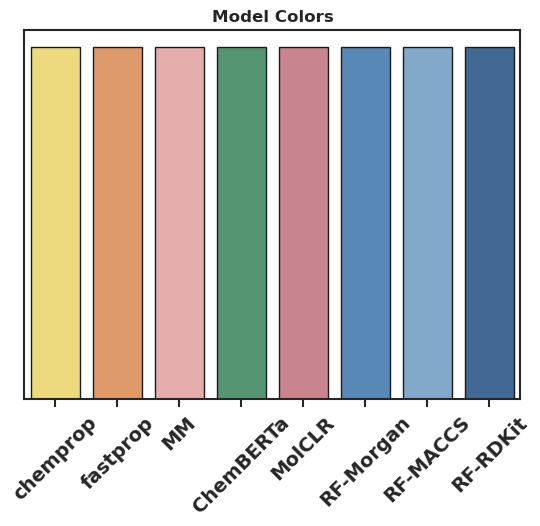

In [9]:
sns.barplot(x=list(model_colors.keys()), y=[1]*8, palette=model_colors)
plt.xticks(rotation=45)
plt.yticks([])
plt.title("Model Colors")
plt.show()

In [10]:
def plot_subset_rmse_comparison(summary_df, title, figsize=(8, 7), dpi=600, save_path=None):
    """
    Create a bar plot with subsets on the x-axis and different colors for each model.
    Includes error bars for models that have standard deviation data.
    Uses consistent model order across all plots.
    
    Args:
        summary_df: DataFrame with Model, Subset, RMSE and RMSE_std columns
        title: Title for the plot
        figsize: Size of the figure
        dpi: Resolution of the figure
    """
    import matplotlib.gridspec as gridspec
    
    # Prepare data for plotting
    plot_df = prepare_plot_data(summary_df)
    
    # Filter models to only include those in the data
    available_models = plot_df['Model'].unique()
    model_order = [model for model in fixed_model_order if model in available_models]
    
    # Create figure with GridSpec for legend area on top and plot area below
    fig = plt.figure(figsize=figsize, dpi=dpi)
    outer_gs = gridspec.GridSpec(2, 1, height_ratios=[0.15, 0.85])  # 15% for legend, 85% for plot
    
    # Use the top section for legend
    legend_ax = fig.add_subplot(outer_gs[0])
    legend_ax.axis('off')  # Hide the axis
    
    # Use the bottom section for the actual plot
    ax1 = fig.add_subplot(outer_gs[1])
    
    # Calculate position for bars
    subset_positions = {subset: i for i, subset in enumerate(subset_labels)}
    bar_width = 0.1
    
    # List to hold legend handles and labels
    legend_handles = []
    legend_labels = []
    
    # Plot bars for each model
    for i, model in enumerate(model_order):
        model_data = plot_df[plot_df['Model'] == model]
        
        # Extract values for this model
        x_values = []
        y_values = []
        yerr_values = []
        
        for subset in subset_labels:
            subset_row = model_data[model_data['Subset'] == subset]
            if not subset_row.empty:
                x_values.append(subset_positions[subset] + (i - len(model_order)/2 + 0.5) * bar_width)
                y_values.append(subset_row['RMSE'].values[0])
                # Add error bars for models with standard deviation data
                if 'RMSE_std' in subset_row.columns and not pd.isna(subset_row['RMSE_std'].values[0]):
                    yerr_values.append(subset_row['RMSE_std'].values[0])
                else:
                    yerr_values.append(0)
        
        # Plot bars for this model
        color = model_colors.get(model, f'C{i}')
        if model in models_with_error_bars and any(yerr > 0 for yerr in yerr_values):
            # Plot with error bars for models that have them
            bars = ax1.bar(x_values, y_values, width=bar_width,
                     color=color, edgecolor='black', linewidth=1)
            ax1.errorbar(x_values, y_values, yerr=yerr_values, fmt='none', ecolor='black',
                         elinewidth=1.5, capsize=3)
        else:
            # Plot without error bars for models that don't have them
            bars = ax1.bar(x_values, y_values, width=bar_width,
                     color=color, edgecolor='black', linewidth=1)
        
        # Add this model to legend handles
        legend_handles.append(bars[0])
        legend_labels.append(model)
        
        if model not in model_colors:
            print(f"Warning: Using default color for {model}")
    
    # Customize plot
    ax1.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSE (kcal/mol)")
    ax1.set_xticks(list(subset_positions.values()), list(subset_positions.keys()))
    
    # Add y-axis limit for better visualization
    ax1.set_ylim(0, plot_df['RMSE'].max() * 1.1)
    
    # Calculate number of columns for legend - we want 3 rows
    # For 7 models: 3+2+2 arrangement (3 models per row for first row, 2 for second and third)
    ncols = 3  # Fixed to 3 columns for first row
    
    # Create the legend in the top axis with three rows
    legend = legend_ax.legend(legend_handles, legend_labels, 
                           loc='center', frameon=False,
                           ncol=ncols, handlelength=2)
    
    # Adjust spacing between subplots
    fig.tight_layout()
    # Add some extra space for the legend
    plt.subplots_adjust(top=0.85)
    
    # Save figure if path is provided
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
    
    return fig

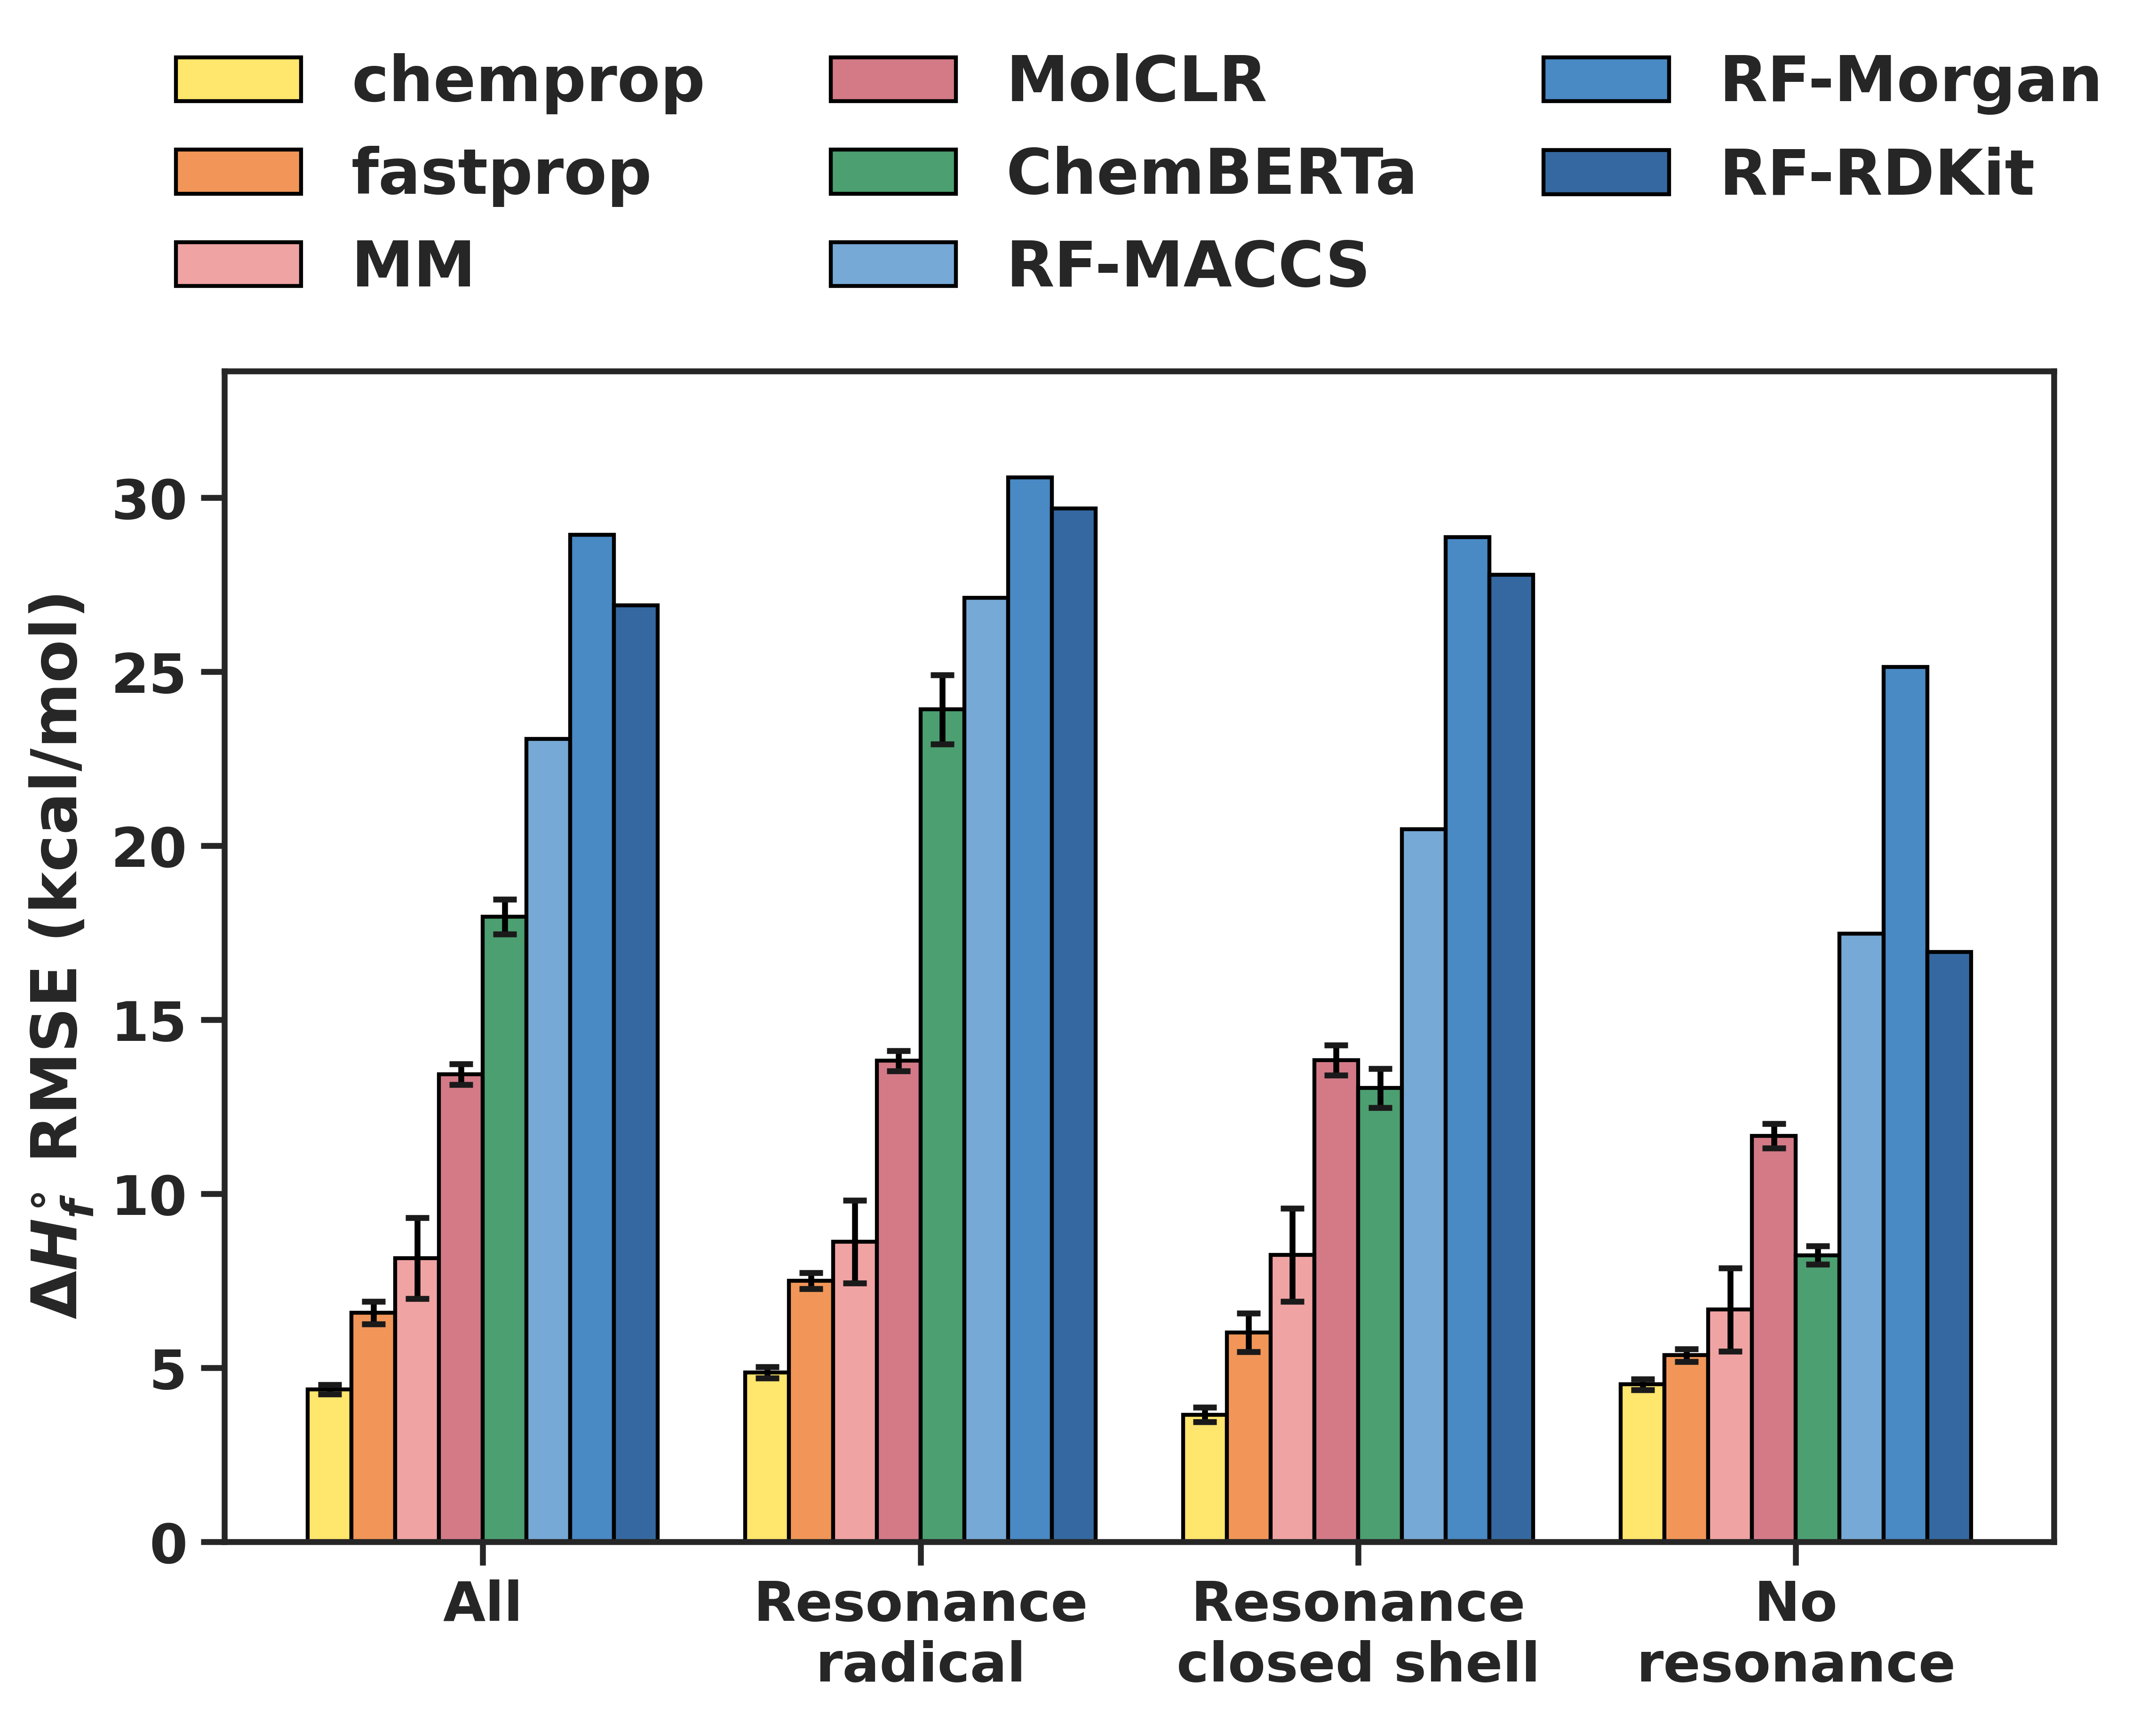

In [11]:
# Plot RMSE comparison for augmented test set
test_rmse_plot = plot_subset_rmse_comparison(
    test_summary_df,
    'RMSE Comparison Across Subsets (Test Set)',
    save_path='/home/akshatz/bond_order_free/figures_si/baselines.pdf'
)
test_rmse_plot.show()

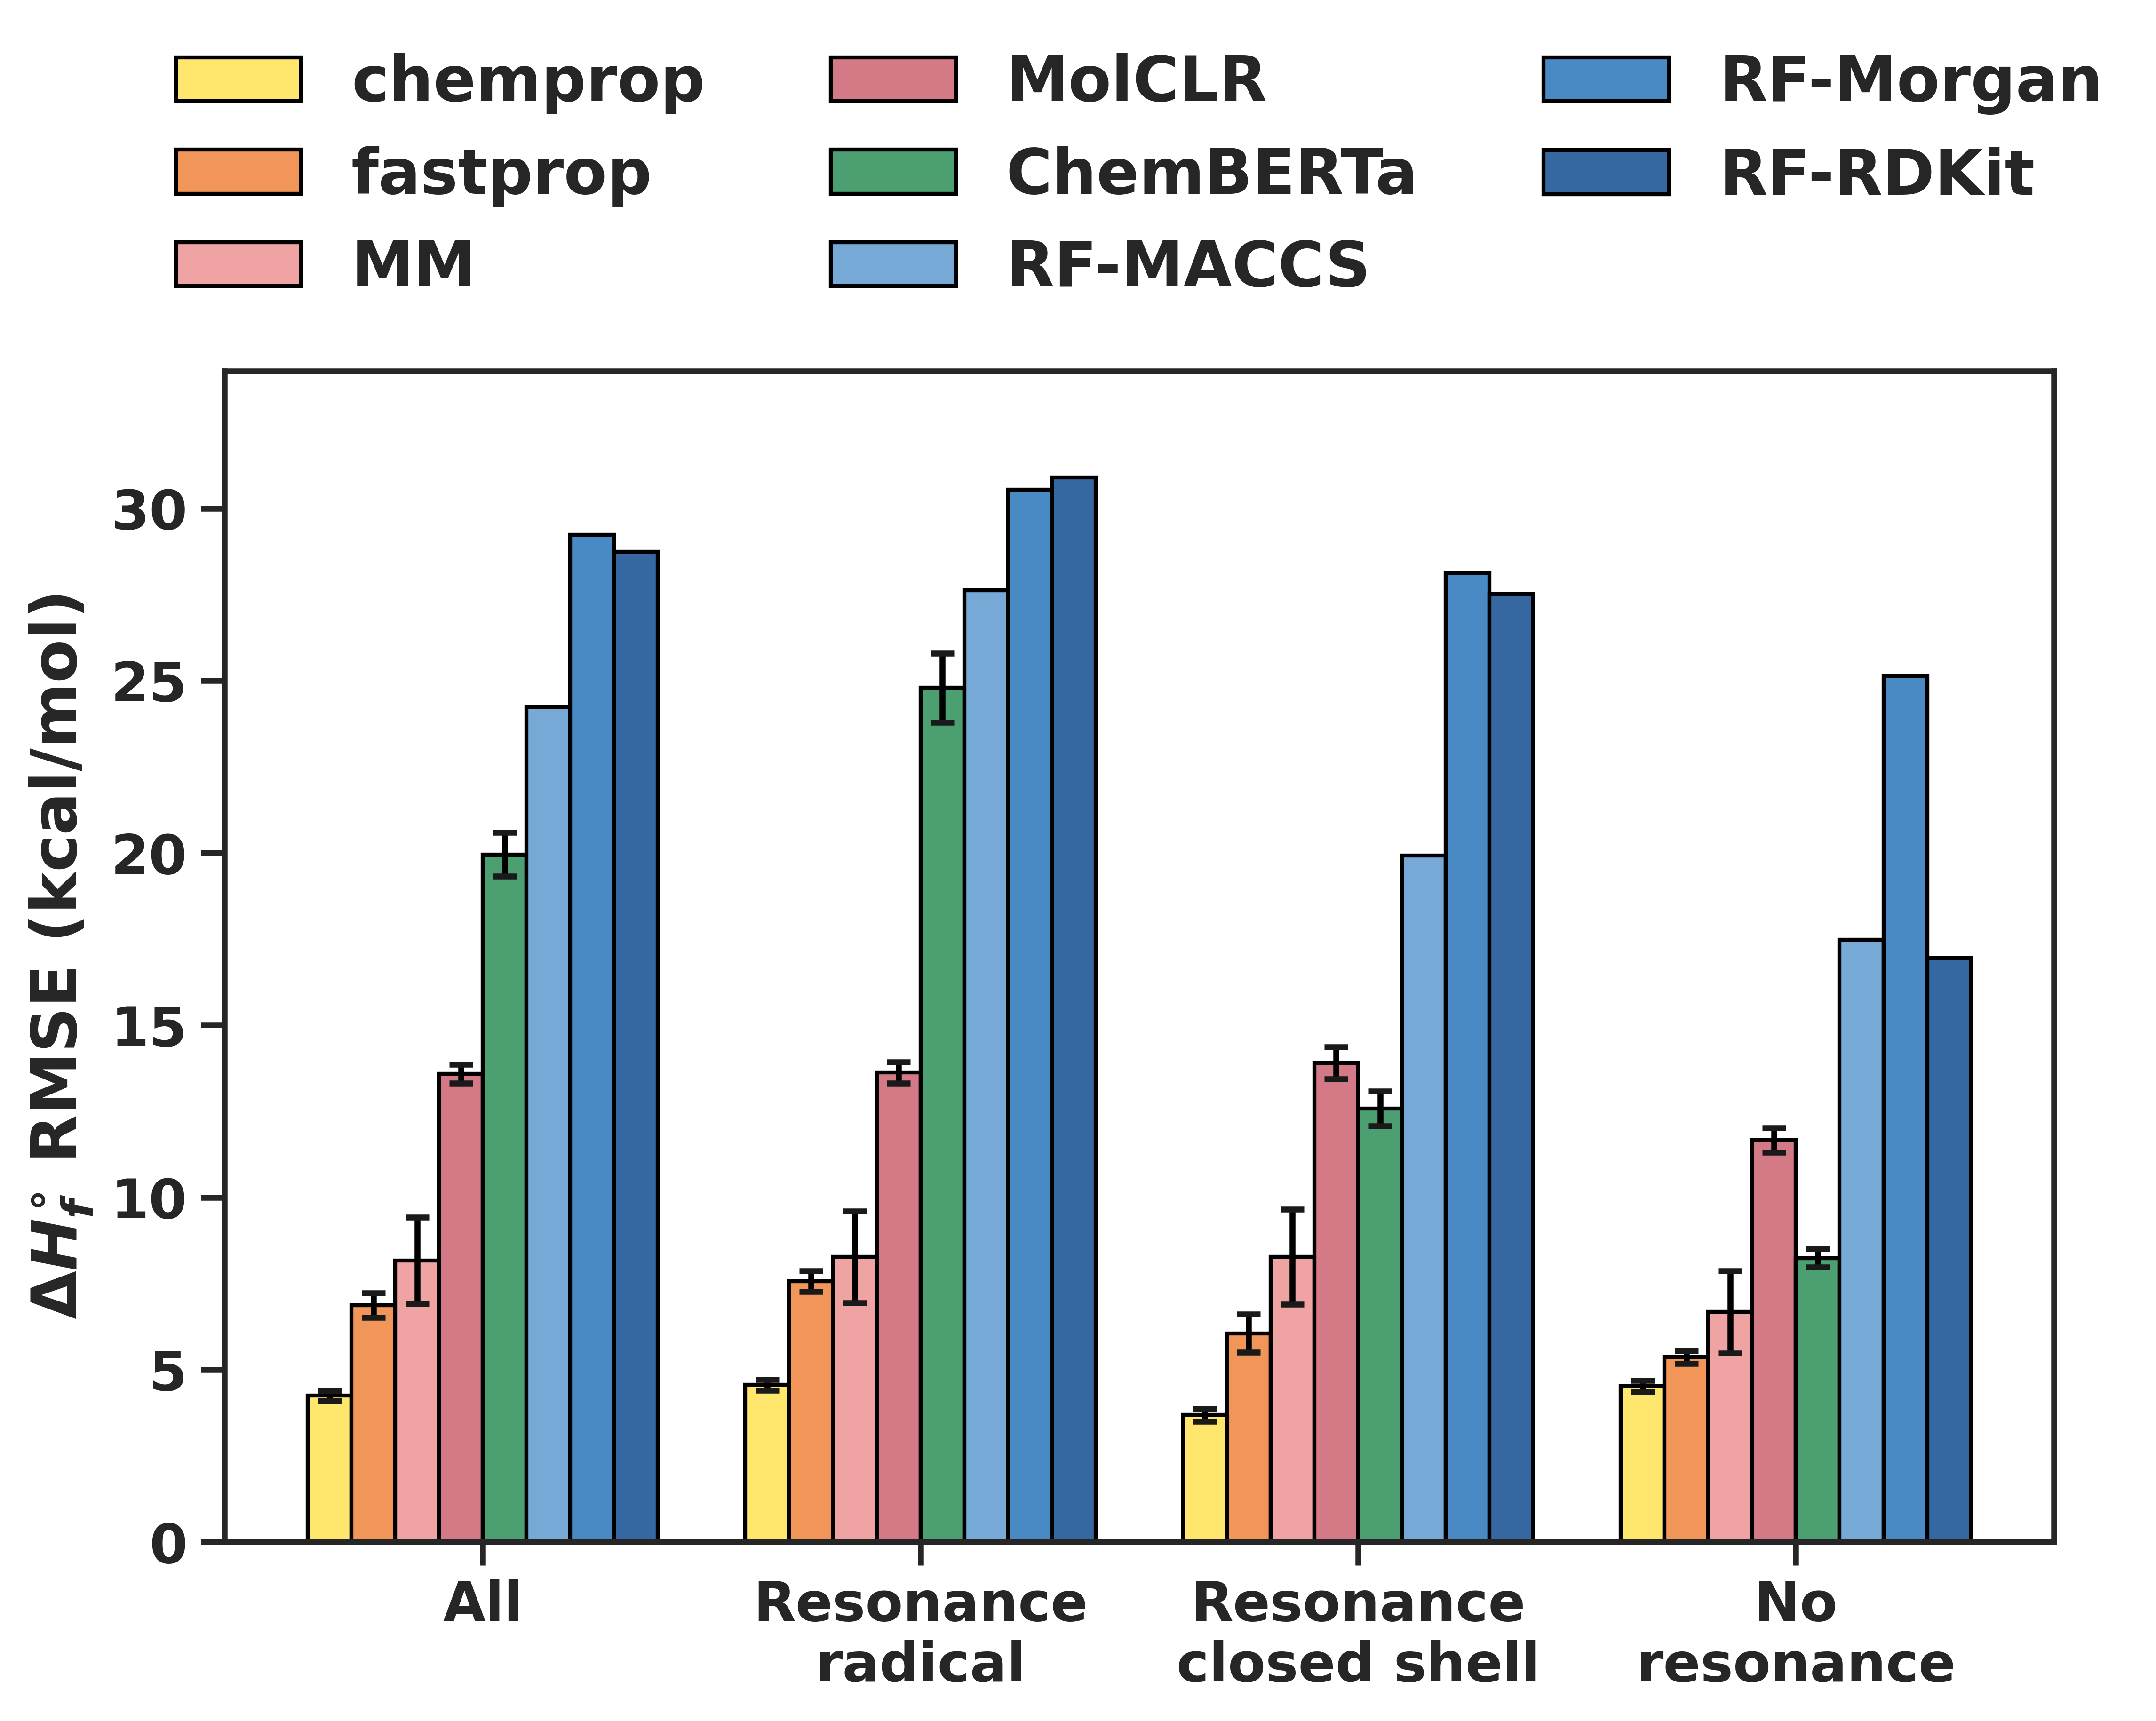

In [12]:
# Plot RMSE comparison for augmented test set
aug_test_rmse_plot = plot_subset_rmse_comparison(
    aug_test_summary_df,
    'RMSE Comparison Across Subsets (Augmented Test Set)'
)
aug_test_rmse_plot.show()

In [13]:
# def plot_resonance_metrics(summary_df, metric, title, figsize=(16, 9), dpi=600):
#     """
#     Create a bar plot for resonance metrics with subsets on the x-axis.
#     Includes error bars for models that have standard deviation data.
#     Uses consistent model order across all plots.
    
#     Args:
#         summary_df: DataFrame with Model, Subset, and metric columns
#         metric: Column name of the metric to plot (either 'RMSRR' or 'RMSMRD')
#         title: Title for the plot
#         figsize: Size of the figure
#         dpi: Resolution of the figure
#     """
#     # Prepare data for plotting
#     plot_df = prepare_plot_data(summary_df)
    
#     # Filter for resonance subsets and non-null metric values
#     res_subsets = ['Resonance\nradical', 'Resonance\nclosed shell']
#     plot_df = plot_df[plot_df['Subset'].isin(res_subsets) & plot_df[metric].notnull()]
    
#     # Filter models to only include those in the data
#     available_models = plot_df['Model'].unique()
#     model_order = [model for model in fixed_model_order if model in available_models]
    
#     # Create figure
#     # plt.figure(figsize=figsize)
#     fig, (ax1) = plt.subplots(1,1, figsize=(16, 9), dpi=600)
    
#     # Calculate position for bars
#     subset_positions = {subset: i for i, subset in enumerate(res_subsets)}
#     bar_width = 0.12
    
#     # Plot bars for each model
#     for i, model in enumerate(model_order):
#         model_data = plot_df[plot_df['Model'] == model]
        
#         # Extract values for this model
#         x_values = []
#         y_values = []
#         yerr_values = []
        
#         for subset in res_subsets:
#             subset_row = model_data[model_data['Subset'] == subset]
#             if not subset_row.empty and not pd.isna(subset_row[metric].values[0]):
#                 x_values.append(subset_positions[subset] + (i - len(model_order)/2 + 0.5) * bar_width)
#                 y_values.append(subset_row[metric].values[0])
                
#                 # Add error bars for models with standard deviation data
#                 std_col = f"{metric}_std"
#                 if std_col in subset_row.columns and not pd.isna(subset_row[std_col].values[0]):
#                     yerr_values.append(subset_row[std_col].values[0])
#                 else:
#                     yerr_values.append(0)
        
#         # Plot bars for this model
#         color = model_colors.get(model, f'C{i}')
#         if model in models_with_error_bars and any(yerr > 0 for yerr in yerr_values):
#             # Plot with error bars for models that have them
#             ax1.bar(x_values, y_values, width=bar_width, label=model,
#                      color=color, edgecolor='black', linewidth=1)
#             ax1.errorbar(x_values, y_values, yerr=yerr_values, fmt='none', ecolor='black',
#                           elinewidth=1.5, capsize=3)
#         else:
#             # Plot without error bars for models that don't have them
#             ax1.bar(x_values, y_values, width=bar_width, label=model,
#                      color=color, edgecolor='black', linewidth=1)
    
#     # Customize plot
#     # ax1.set_xlabel('Subset')
#     ax1.set_ylabel(fr"$\Delta H_{{f}}^{{\circ}}$ {metric} (kcal/mol)")
#     ax1.set_xticks(list(subset_positions.values()), list(subset_positions.keys()))
#     # plt.title(title, fontsize=16)
#     # plt.grid(axis='y', linestyle='--', alpha=0.7)
#     # plt.legend(title='Model', loc='upper left', fontsize=12)
#     legend = ax1.legend(title='', loc = 'upper left', frameon=False, handlelength = 2)
    
#     # Add y-axis limit for better visualization
#     ax1.set_ylim(0, plot_df[metric].max() * 1.1)
    
#     fig.tight_layout()
#     return plt

In [14]:
# # Plot RMSRR comparison for augmented test set
# rmsrr_plot = plot_resonance_metrics(
#     aug_test_summary_df,
#     'RMSRR',
#     'RMSRR Comparison Across Resonance Subsets'
# )
# rmsrr_plot.show()

# # Plot RMSMRD comparison for augmented test set
# rmsmrd_plot = plot_resonance_metrics(
#     aug_test_summary_df,
#     'RMSMRD',
#     'RMSMRD Comparison Across Resonance Subsets'
# )
# rmsmrd_plot.show()

In [37]:
def plot_aug_test_three_panel(aug_test_summary_df, figsize=(16, 8), dpi=350, save_path=None):
    """
    Create a three-panel figure showing RMSE, RMSRR, and RMSMRD metrics for the augmented test set.
    Similar to the plot in final_figures.ipynb but for multiple baseline models.
    
    Args:
        aug_test_summary_df: DataFrame with summary metrics
        figsize: Size of the figure
        dpi: Resolution of the figure
        save_path: Path to save the figure (optional)
    """
    import matplotlib.gridspec as gridspec
    
    # Prepare data for plotting
    plot_df = prepare_plot_data(aug_test_summary_df)
    
    # Filter models to only include those in the data
    available_models = plot_df['Model'].unique()
    model_order = [model for model in fixed_model_order if model in available_models]
    
    # Create figure with GridSpec
    fig = plt.figure(figsize=figsize, dpi=dpi)
    # Create a gridspec for the top section (for legend) and bottom section (for plots)
    outer_gs = gridspec.GridSpec(2, 1, height_ratios=[0.15, 0.85])  # Adjust ratio as needed for legend space
    
    # Use the top section for legend
    legend_ax = fig.add_subplot(outer_gs[0])
    legend_ax.axis('off')  # Hide the axis
    
    # Use the bottom section for the three panels
    gs = gridspec.GridSpecFromSubplotSpec(1, 3, subplot_spec=outer_gs[1], width_ratios=[2, 1.05, 1.05])
    
    # Create subplots and assign them to the grid spec
    ax1 = fig.add_subplot(gs[0])  # RMSE plot
    ax2 = fig.add_subplot(gs[1])  # RMSRR plot
    ax3 = fig.add_subplot(gs[2])  # RMSMRD plot
    
    # Define x-positions and spacing - use the same values for all panels
    subset_labels_rmse = ['All', 'Resonance\nradical', 'Resonance\nclosed shell', 'No\nresonance']
    subset_labels_res = ['Resonance\nradical', 'Resonance\nclosed shell']
    
    # Common parameters for consistent bar widths across all panels
    num_models = len(model_order)
    width = 0.11  # Fixed width for all bars in all panels
    
    # Define base positions for each subset group - these are fixed points on the x-axis
    base_positions = {'All': 0, 'Resonance\nradical': 1, 'Resonance\nclosed shell': 2, 'No\nresonance': 3}
    
    # Total width needed for all bars in a group
    group_width = num_models * width
    
    # Define offsets for each model within a group
    model_offsets = [(i - (num_models-1)/2) * width for i in range(num_models)]
    
    # List to hold legend handles and labels
    legend_handles = []
    legend_labels = []
    
    # Plot RMSE bars for each model
    for i, model in enumerate(model_order):
        model_data = plot_df[plot_df['Model'] == model]
        offset = model_offsets[i]  # Get this model's offset within groups
        color = model_colors.get(model, f'C{i}')
        
        # --- RMSE Panel ---
        rmse_x_positions = []
        rmse_values = []
        rmse_errors = []
        
        for subset in subset_labels_rmse:
            subset_row = model_data[model_data['Subset'] == subset]
            if not subset_row.empty:
                # Calculate x position: base position + model's offset within the group
                x_pos = base_positions[subset] + offset
                rmse_x_positions.append(x_pos)
                rmse_values.append(subset_row['RMSE'].values[0])
                
                if 'RMSE_std' in subset_row.columns and not pd.isna(subset_row['RMSE_std'].values[0]):
                    rmse_errors.append(subset_row['RMSE_std'].values[0])
                else:
                    rmse_errors.append(0)
            else:
                # If data is missing, still maintain position for consistency
                x_pos = base_positions[subset] + offset
                rmse_x_positions.append(x_pos)
                rmse_values.append(0)
                rmse_errors.append(0)
        
        # Plot RMSE bars
        bars = ax1.bar(
            rmse_x_positions,
            rmse_values,
            yerr=rmse_errors,
            width=width,
            color=color,
            edgecolor='black',
            ecolor='black',
            capsize=2.5,
        )
        
        # Add this model to legend_handles for later use (only once)
        legend_handles.append(bars[0])
        legend_labels.append(model)
        
        # --- RMSRR Panel ---
        rmsrr_x_positions = []
        rmsrr_values = []
        rmsrr_errors = []
        
        for subset in subset_labels_res:
            subset_row = model_data[model_data['Subset'] == subset]
            if not subset_row.empty and not pd.isna(subset_row['RMSRR'].values[0]):
                # Use the same positioning logic as the RMSE panel
                x_pos = base_positions[subset] + offset
                rmsrr_x_positions.append(x_pos)
                rmsrr_values.append(subset_row['RMSRR'].values[0])
                
                if 'RMSRR_std' in subset_row.columns and not pd.isna(subset_row['RMSRR_std'].values[0]):
                    rmsrr_errors.append(subset_row['RMSRR_std'].values[0])
                else:
                    rmsrr_errors.append(0)
            else:
                # If data is missing, still maintain position for consistency
                x_pos = base_positions[subset] + offset
                rmsrr_x_positions.append(x_pos)
                rmsrr_values.append(0)
                rmsrr_errors.append(0)
        
        # Plot RMSRR bars using the same width as RMSE bars
        ax2.bar(
            rmsrr_x_positions,
            rmsrr_values,
            yerr=rmsrr_errors,
            width=width,  # Same width as RMSE bars
            color=color,
            edgecolor='black',
            ecolor='black',
            capsize=2.5,
        )
        
        # --- RMSMRD Panel ---
        rmsmrd_x_positions = []
        rmsmrd_values = []
        rmsmrd_errors = []
        
        for subset in subset_labels_res:
            subset_row = model_data[model_data['Subset'] == subset]
            if not subset_row.empty and not pd.isna(subset_row['RMSMRD'].values[0]):
                # Use the same positioning logic as the other panels
                x_pos = base_positions[subset] + offset
                rmsmrd_x_positions.append(x_pos)
                rmsmrd_values.append(subset_row['RMSMRD'].values[0])
                
                if 'RMSMRD_std' in subset_row.columns and not pd.isna(subset_row['RMSMRD_std'].values[0]):
                    rmsmrd_errors.append(subset_row['RMSMRD_std'].values[0])
                else:
                    rmsmrd_errors.append(0)
            else:
                # If data is missing, still maintain position for consistency
                x_pos = base_positions[subset] + offset
                rmsmrd_x_positions.append(x_pos)
                rmsmrd_values.append(0)
                rmsmrd_errors.append(0)
        
        # Plot RMSMRD bars using the same width as other bars
        ax3.bar(
            rmsmrd_x_positions,
            rmsmrd_values,
            yerr=rmsmrd_errors,
            width=width,  # Same width as other panels
            color=color,
            edgecolor='black',
            ecolor='black',
            capsize=2.5,
        )
    
    # Set x-ticks at the center of each group
    ax1.set_xticks(list(base_positions.values()), list(base_positions.keys()))
    ax1.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSE (kcal/mol)")
    ax1.text(0.9, 0.9, "(a)", transform=ax1.transAxes, fontsize=18)
    ax1.set_ylim([0, plot_df['RMSE'].max() * 1.1])
    
    # Set x-ticks for resonance panels, using the same positioning logic
    resonance_tick_positions = [base_positions[subset] for subset in subset_labels_res]
    
    ax2.set_xticks(resonance_tick_positions, subset_labels_res)
    ax2.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSRR (kcal/mol)")
    ax2.text(0.825, 0.9, "(b)", transform=ax2.transAxes, fontsize=19)
    
    # Find maximum value for consistent y-axis limits
    rmsrr_values = plot_df[plot_df['RMSRR'].notnull()]['RMSRR']
    rmsmrd_values = plot_df[plot_df['RMSMRD'].notnull()]['RMSMRD']
    
    max_resonance_metric = max(
        rmsrr_values.max() if not rmsrr_values.empty else 0,
        rmsmrd_values.max() if not rmsmrd_values.empty else 0
    )
    ax2.set_ylim([0, max_resonance_metric * 1.1])
    
    # Apply the same x-ticks to RMSMRD panel
    ax3.set_xticks(resonance_tick_positions, subset_labels_res) 
    ax3.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSMRD (kcal/mol)")
    ax3.text(0.825, 0.9, "(c)", transform=ax3.transAxes, fontsize=19)
    ax3.set_ylim([0, max_resonance_metric * 1.1])
    
    # Create the legend in the top axis with multiple rows and columns
    ncol = min(4, len(legend_handles))  # Use 4 columns or fewer if there are fewer models
    legend = legend_ax.legend(legend_handles, legend_labels, 
                             loc='center', frameon=False,
                             ncol=ncol, handlelength=2)
    
    # Adjust spacing between subplots
    fig.tight_layout()
    # Add some extra space for the legend
    plt.subplots_adjust(top=0.85)
    
    # Save figure if path is provided
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
    
    return fig

In [38]:
def plot_aug_test_three_panel_vertical(aug_test_summary_df, figsize=(12, 8), dpi=350, save_path=None):
    """
    Create a three-panel figure showing RMSE, RMSRR, and RMSMRD metrics for the augmented test set.
    Uses a vertical layout: RMSE panel on top, RMSRR and RMSMRD panels side by side below.
    
    Args:
        aug_test_summary_df: DataFrame with summary metrics
        figsize: Size of the figure
        dpi: Resolution of the figure
        save_path: Path to save the figure (optional)
    """
    import matplotlib.gridspec as gridspec
    
    # Prepare data for plotting
    plot_df = prepare_plot_data(aug_test_summary_df)
    
    # Filter models to only include those in the data
    available_models = plot_df['Model'].unique()
    model_order = [model for model in fixed_model_order if model in available_models]
    
    # Create figure with GridSpec
    fig = plt.figure(figsize=figsize, dpi=dpi)
    # Create a gridspec for the top section (for legend) and bottom section (for plots)
    outer_gs = gridspec.GridSpec(2, 1, height_ratios=[0.08, 0.92])  # Reduced legend space for better spacing
    
    # Use the top section for legend
    legend_ax = fig.add_subplot(outer_gs[0])
    legend_ax.axis('off')  # Hide the axis
    
    # Use the bottom section for the three panels in 2x2 layout
    # Top row spans both columns (for RMSE), bottom row has two separate panels
    gs = gridspec.GridSpecFromSubplotSpec(2, 2, subplot_spec=outer_gs[1], 
                                         height_ratios=[1, 1], width_ratios=[1, 1],
                                         hspace=0.4)  # Add vertical spacing between rows
    
    # Create subplots and assign them to the grid spec
    ax1 = fig.add_subplot(gs[0, :])  # RMSE plot - spans both columns of top row
    ax2 = fig.add_subplot(gs[1, 0])  # RMSRR plot - left column of bottom row
    ax3 = fig.add_subplot(gs[1, 1])  # RMSMRD plot - right column of bottom row
    
    # Define x-positions and spacing - use the same values for all panels
    subset_labels_rmse = ['All', 'Resonance\nradical', 'Resonance\nclosed shell', 'No\nresonance']
    subset_labels_res = ['Resonance\nradical', 'Resonance\nclosed shell']
    
    # Common parameters for consistent bar widths across all panels
    num_models = len(model_order)
    width = 0.12  # Fixed width for all bars in all panels
    
    # Define base positions for each subset group - these are fixed points on the x-axis
    base_positions = {'All': 0, 'Resonance\nradical': 1, 'Resonance\nclosed shell': 2, 'No\nresonance': 3}
    
    # Total width needed for all bars in a group
    group_width = num_models * width
    
    # Define offsets for each model within a group
    model_offsets = [(i - (num_models-1)/2) * width for i in range(num_models)]
    
    # List to hold legend handles and labels
    legend_handles = []
    legend_labels = []
    
    # Plot RMSE bars for each model
    for i, model in enumerate(model_order):
        model_data = plot_df[plot_df['Model'] == model]
        offset = model_offsets[i]  # Get this model's offset within groups
        color = model_colors.get(model, f'C{i}')
        
        # --- RMSE Panel ---
        rmse_x_positions = []
        rmse_values = []
        rmse_errors = []
        
        for subset in subset_labels_rmse:
            subset_row = model_data[model_data['Subset'] == subset]
            if not subset_row.empty:
                # Calculate x position: base position + model's offset within the group
                x_pos = base_positions[subset] + offset
                rmse_x_positions.append(x_pos)
                rmse_values.append(subset_row['RMSE'].values[0])
                
                if 'RMSE_std' in subset_row.columns and not pd.isna(subset_row['RMSE_std'].values[0]):
                    rmse_errors.append(subset_row['RMSE_std'].values[0])
                else:
                    rmse_errors.append(0)
            else:
                # If data is missing, still maintain position for consistency
                x_pos = base_positions[subset] + offset
                rmse_x_positions.append(x_pos)
                rmse_values.append(0)
                rmse_errors.append(0)
        
        # Plot RMSE bars
        bars = ax1.bar(
            rmse_x_positions,
            rmse_values,
            yerr=rmse_errors,
            width=width,
            color=color,
            edgecolor='black',
            ecolor='black',
            capsize=2.5,
        )
        
        # Add this model to legend_handles for later use (only once)
        legend_handles.append(bars[0])
        legend_labels.append(model)
        
        # --- RMSRR Panel ---
        rmsrr_x_positions = []
        rmsrr_values = []
        rmsrr_errors = []
        
        for subset in subset_labels_res:
            subset_row = model_data[model_data['Subset'] == subset]
            if not subset_row.empty and not pd.isna(subset_row['RMSRR'].values[0]):
                # Use the same positioning logic as the RMSE panel
                x_pos = base_positions[subset] + offset
                rmsrr_x_positions.append(x_pos)
                rmsrr_values.append(subset_row['RMSRR'].values[0])
                
                if 'RMSRR_std' in subset_row.columns and not pd.isna(subset_row['RMSRR_std'].values[0]):
                    rmsrr_errors.append(subset_row['RMSRR_std'].values[0])
                else:
                    rmsrr_errors.append(0)
            else:
                # If data is missing, still maintain position for consistency
                x_pos = base_positions[subset] + offset
                rmsrr_x_positions.append(x_pos)
                rmsrr_values.append(0)
                rmsrr_errors.append(0)
        
        # Plot RMSRR bars using the same width as RMSE bars
        ax2.bar(
            rmsrr_x_positions,
            rmsrr_values,
            yerr=rmsrr_errors,
            width=width,  # Same width as RMSE bars
            color=color,
            edgecolor='black',
            ecolor='black',
            capsize=2.5,
        )
        
        # --- RMSMRD Panel ---
        rmsmrd_x_positions = []
        rmsmrd_values = []
        rmsmrd_errors = []
        
        for subset in subset_labels_res:
            subset_row = model_data[model_data['Subset'] == subset]
            if not subset_row.empty and not pd.isna(subset_row['RMSMRD'].values[0]):
                # Use the same positioning logic as the other panels
                x_pos = base_positions[subset] + offset
                rmsmrd_x_positions.append(x_pos)
                rmsmrd_values.append(subset_row['RMSMRD'].values[0])
                
                if 'RMSMRD_std' in subset_row.columns and not pd.isna(subset_row['RMSMRD_std'].values[0]):
                    rmsmrd_errors.append(subset_row['RMSMRD_std'].values[0])
                else:
                    rmsmrd_errors.append(0)
            else:
                # If data is missing, still maintain position for consistency
                x_pos = base_positions[subset] + offset
                rmsmrd_x_positions.append(x_pos)
                rmsmrd_values.append(0)
                rmsmrd_errors.append(0)
        
        # Plot RMSMRD bars using the same width as other bars
        ax3.bar(
            rmsmrd_x_positions,
            rmsmrd_values,
            yerr=rmsmrd_errors,
            width=width,  # Same width as other panels
            color=color,
            edgecolor='black',
            ecolor='black',
            capsize=2.5,
        )
    
    # Set x-ticks at the center of each group
    ax1.set_xticks(list(base_positions.values()), list(base_positions.keys()))
    ax1.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSE (kcal/mol)")
    ax1.text(0.95, 0.9, "(a)", transform=ax1.transAxes, fontsize=18)
    ax1.set_ylim([0, plot_df['RMSE'].max() * 1.1])
    
    # Set x-ticks for resonance panels, using the same positioning logic
    resonance_tick_positions = [base_positions[subset] for subset in subset_labels_res]
    
    ax2.set_xticks(resonance_tick_positions, subset_labels_res)
    ax2.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSRR (kcal/mol)")
    ax2.text(0.85, 0.9, "(b)", transform=ax2.transAxes, fontsize=18)
    
    # Find maximum value for consistent y-axis limits
    rmsrr_values = plot_df[plot_df['RMSRR'].notnull()]['RMSRR']
    rmsmrd_values = plot_df[plot_df['RMSMRD'].notnull()]['RMSMRD']
    
    max_resonance_metric = max(
        rmsrr_values.max() if not rmsrr_values.empty else 0,
        rmsmrd_values.max() if not rmsmrd_values.empty else 0
    )
    ax2.set_ylim([0, max_resonance_metric * 1.1])
    
    # Apply the same x-ticks to RMSMRD panel
    ax3.set_xticks(resonance_tick_positions, subset_labels_res) 
    ax3.set_ylabel(r"$\Delta H_{f}^{\circ}$ RMSMRD (kcal/mol)")
    ax3.text(0.85, 0.9, "(c)", transform=ax3.transAxes, fontsize=18)
    ax3.set_ylim([0, max_resonance_metric * 1.1])
    
    # Create the legend in the top axis with multiple rows and columns
    ncol = min(4, len(legend_handles))  # Use 4 columns or fewer if there are fewer models
    legend = legend_ax.legend(legend_handles, legend_labels, 
                             loc='center', frameon=False,
                             ncol=ncol, handlelength=2)
    
    # Adjust spacing between subplots
    fig.tight_layout()
    # Add some extra space for the legend and prevent overlap
    plt.subplots_adjust(top=0.92, hspace=0.4)
    
    # Save figure if path is provided
    if save_path:
        fig.savefig(save_path, bbox_inches="tight")
    
    return fig

In [41]:
# # Create the three-panel plot for augmented test results
# three_panel_fig = plot_aug_test_three_panel_vertical(
#     aug_test_summary_df,
#     save_path="/home/akshatz/bond_order_free/figures_si/baselines_aug.pdf"
# )
# plt.show()

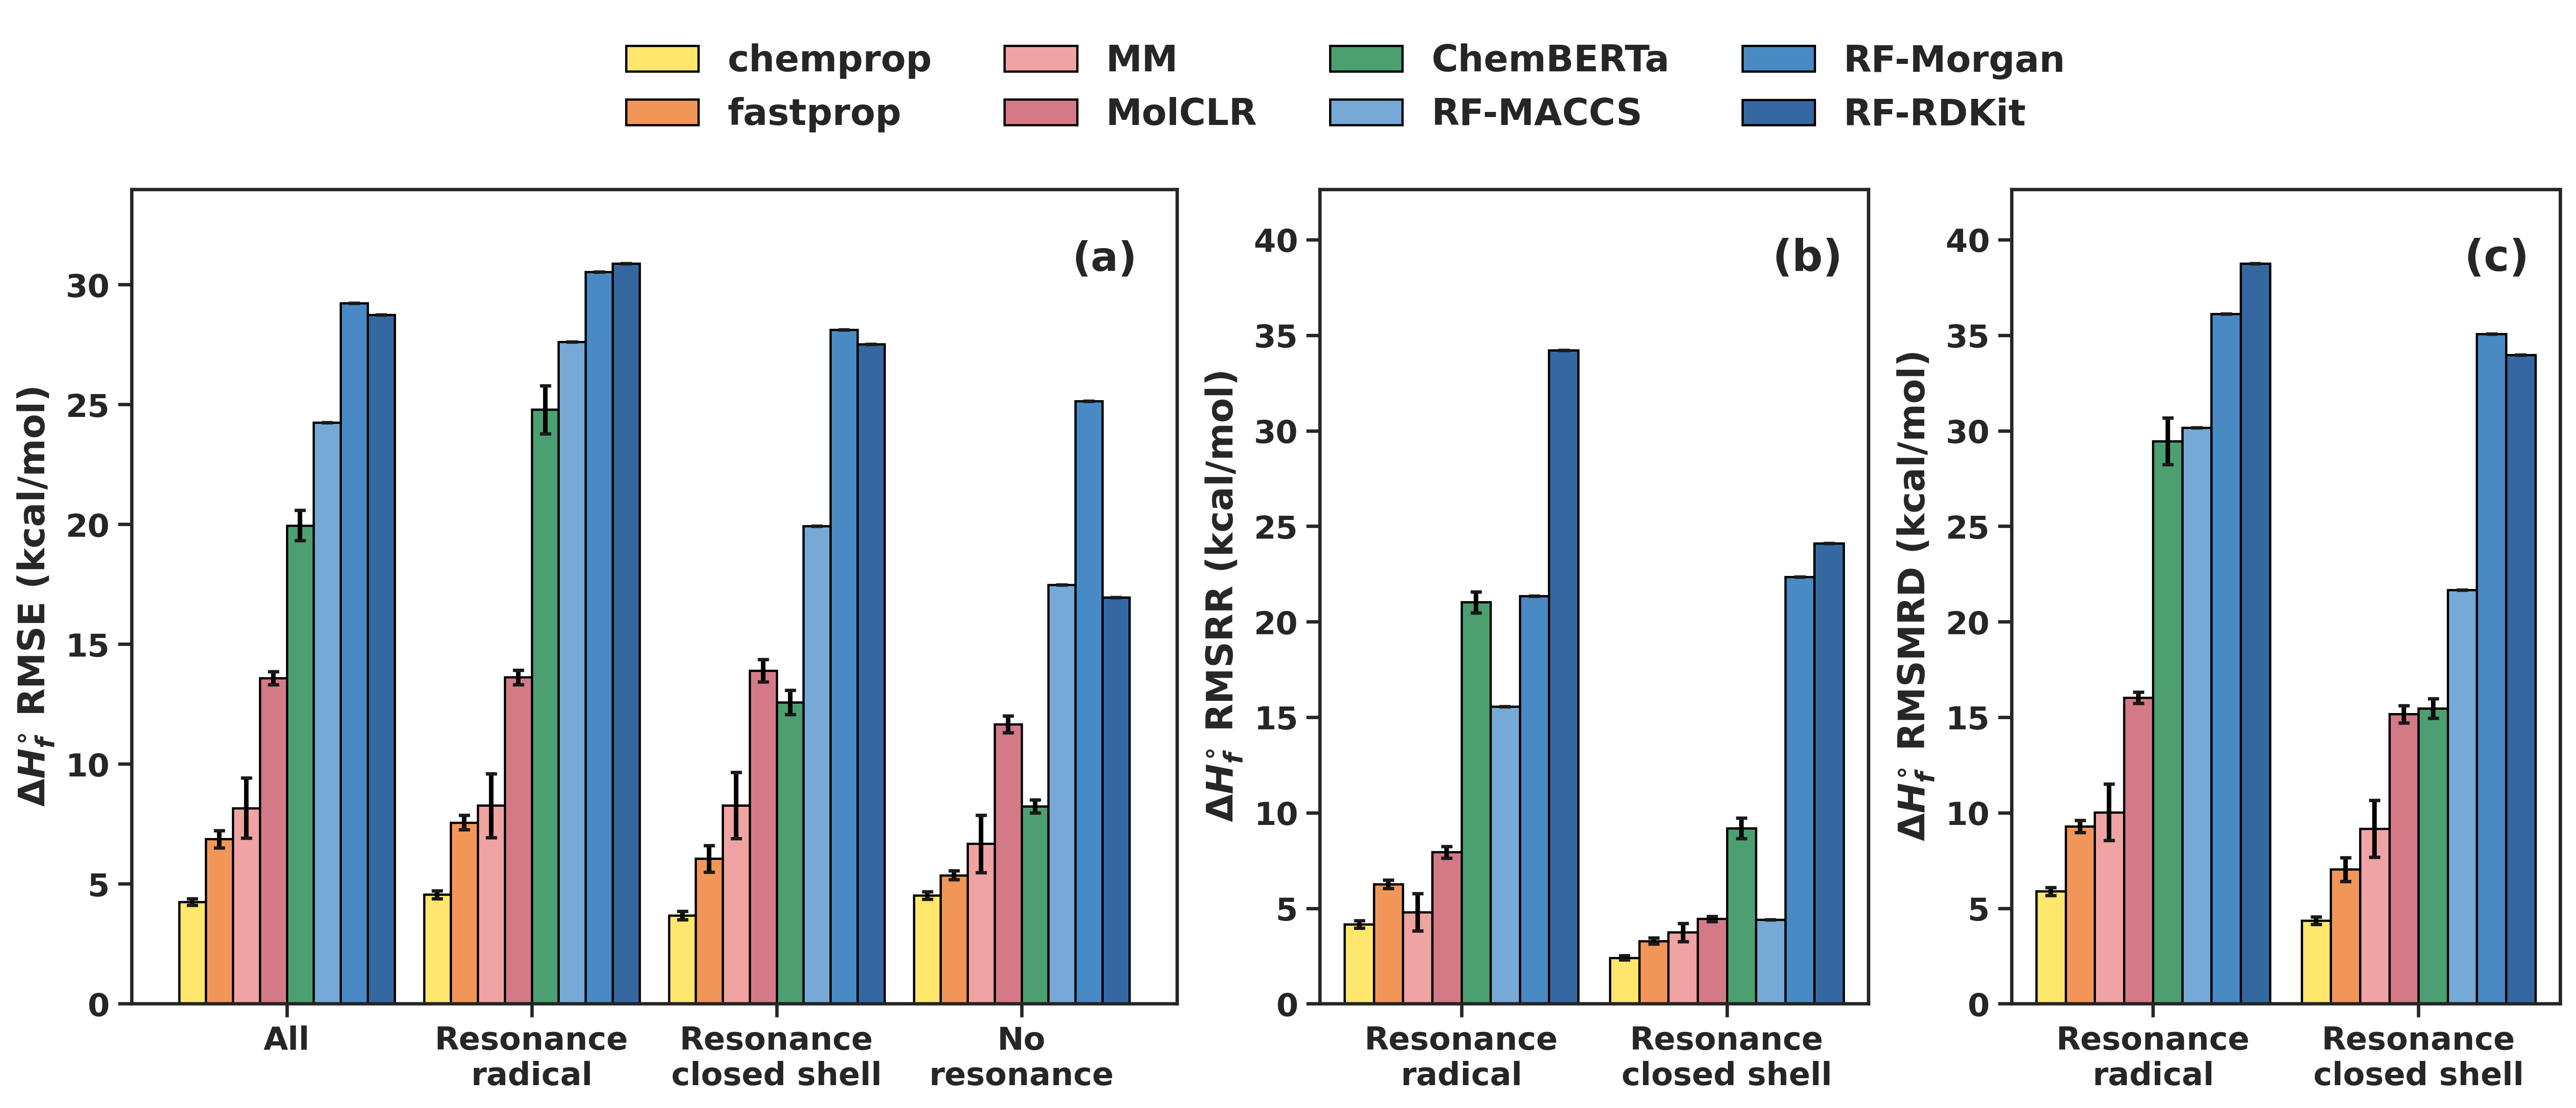

In [42]:
# Create the three-panel plot for augmented test results
three_panel_fig = plot_aug_test_three_panel(
    aug_test_summary_df,
    save_path="/home/akshatz/bond_order_free/figures_si/baselines_aug.pdf"
)
plt.show()